# 91 - 顔Embeddingの空間特性分析

顔認識ベクトル (ArcFace 512次元) に ITQ-LSH を適用する実験シリーズの第1弾。
LSH の性能はベクトル空間の特性（異方性、分布形状）に大きく依存するため、
まず ArcFace 埋め込み空間の特性を詳細に分析する。

## リサーチクエスチョン
- **Q1**: ArcFace 埋め込みの異方性はどの程度か？テキスト埋め込み (E5) と比べてどう違うか？
- L2正規化された単位超球面上の分布特性は ITQ にどう影響するか？

## 入力
- `data/images.duckdb` (`face_detections` テーブル: 75,162 faces)

## 出力
- 異方性メトリクス（固有値スペクトル、条件数、説明分散比）
- コサイン類似度分布（同一人物 vs 他人）
- PCA 2D/3D 可視化
- ITQ 適用に向けた考察

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DB_PATH = Path("../data/images.duckdb")
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 全顔埋め込みを取得（image_catalog とは JOIN しない）
df = conn.execute("""
    SELECT f.face_id, f.image_id, f.embedding, f.person_label, f.gender, f.age, f.det_score
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchdf()

print(f"Total faces: {len(df):,}")
print(f"Labeled persons: {df['person_label'].notna().sum()}")
print(f"Gender: {df['gender'].value_counts().to_dict()}")

# numpy配列に変換
embeddings = np.array([[float(x) for x in emb] for emb in df["embedding"].values])
print(f"Embedding shape: {embeddings.shape}")
print(f"L2 norms - mean: {np.linalg.norm(embeddings, axis=1).mean():.4f}, std: {np.linalg.norm(embeddings, axis=1).std():.6f}")

Total faces: 75,162
Labeled persons: 20
Gender: {'M': 60575, 'F': 14587}


Embedding shape: (75162, 512)


L2 norms - mean: 1.0000, std: 0.000000


## 1. 異方性分析（固有値スペクトル）

PCA で固有値を計算し、ArcFace 埋め込み空間の異方性を定量化する。
`compute_isotropy_score()` を使用。

=== ArcFace 512次元 異方性分析 ===
  total_variance: 0.952026
  top10_variance_ratio: 0.162236
  condition_number: 85007.866049
  max_eigenvalue: 0.033925
  min_eigenvalue: 0.000000


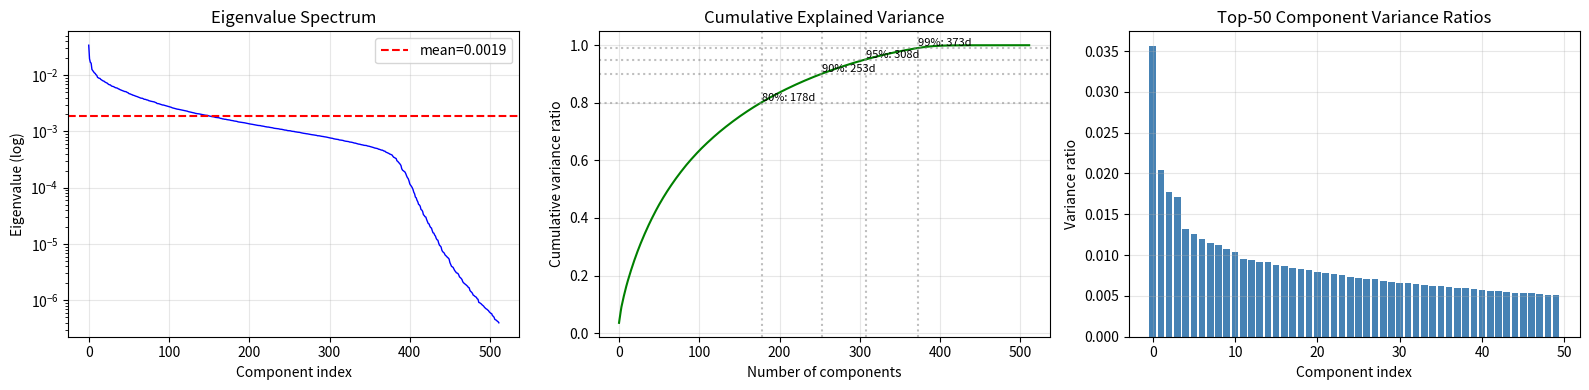


=== ITQ ビット数選定の参考 ===
  64 bits → PCA 64d で累積寄与率 50.5%
  96 bits → PCA 96d で累積寄与率 61.9%
  128 bits → PCA 128d で累積寄与率 70.3%
  256 bits → PCA 256d で累積寄与率 90.3%


In [2]:
from image_vector_poc.search.lsh.whitening import compute_isotropy_score

# 異方性スコア計算
isotropy = compute_isotropy_score(embeddings)
print("=== ArcFace 512次元 異方性分析 ===")
for k, v in isotropy.items():
    print(f"  {k}: {v:.6f}")

# 固有値スペクトルの詳細計算
cov = np.cov(embeddings, rowvar=False)
eigenvalues = np.linalg.eigvalsh(cov)[::-1]  # 降順

# 累積寄与率
cumvar = np.cumsum(eigenvalues) / eigenvalues.sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) 固有値スペクトル（対数スケール）
axes[0].semilogy(eigenvalues, "b-", linewidth=1)
axes[0].set_xlabel("Component index")
axes[0].set_ylabel("Eigenvalue (log)")
axes[0].set_title("Eigenvalue Spectrum")
axes[0].axhline(y=eigenvalues.mean(), color="r", linestyle="--", label=f"mean={eigenvalues.mean():.4f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) 累積寄与率
axes[1].plot(cumvar, "g-", linewidth=1.5)
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n_comp = np.searchsorted(cumvar, threshold) + 1
    axes[1].axhline(y=threshold, color="gray", linestyle=":", alpha=0.5)
    axes[1].axvline(x=n_comp, color="gray", linestyle=":", alpha=0.5)
    axes[1].annotate(f"{threshold*100:.0f}%: {n_comp}d", (n_comp, threshold),
                     fontsize=8, ha="left", va="bottom")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance ratio")
axes[1].set_title("Cumulative Explained Variance")
axes[1].grid(True, alpha=0.3)

# (c) 上位50成分の寄与率
axes[2].bar(range(50), eigenvalues[:50] / eigenvalues.sum(), color="steelblue")
axes[2].set_xlabel("Component index")
axes[2].set_ylabel("Variance ratio")
axes[2].set_title("Top-50 Component Variance Ratios")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ITQ 向けの考察
print("\n=== ITQ ビット数選定の参考 ===")
for n_bits in [64, 96, 128, 256]:
    if n_bits <= len(cumvar):
        print(f"  {n_bits} bits → PCA {n_bits}d で累積寄与率 {cumvar[n_bits-1]*100:.1f}%")

## 2. コサイン類似度分布: 同一人物 vs 他人

ラベル付きデータ (person_label) を使い、同一人物ペアと他人ペアの
コサイン類似度分布を比較。二峰性の確認と分離度を測定する。

In [3]:
# ラベル付き顔 (terada) vs ランダム他者の類似度比較
from numpy.linalg import norm

labeled_mask = df["person_label"].notna()
labeled_df = df[labeled_mask].reset_index(drop=True)
labeled_emb = embeddings[labeled_mask.values]
labels = labeled_df["person_label"].values

unlabeled_mask = ~labeled_mask.values
unlabeled_emb = embeddings[unlabeled_mask]

print(f"Labeled faces (terada): {len(labeled_df)}")
print(f"Unlabeled faces: {len(unlabeled_emb):,}")

# 同一人物ペア (terada 内)
sim_matrix = labeled_emb @ labeled_emb.T
same_person_sims = []
n = len(labeled_emb)
for i in range(n):
    for j in range(i + 1, n):
        same_person_sims.append(sim_matrix[i, j])
same_person_sims = np.array(same_person_sims)

# 他人ペア (terada vs ランダムサンプル)
rng_sim = np.random.default_rng(42)
n_others = min(500, len(unlabeled_emb))
other_idx = rng_sim.choice(len(unlabeled_emb), n_others, replace=False)
other_emb = unlabeled_emb[other_idx]

diff_person_sims = (labeled_emb @ other_emb.T).ravel()

print(f"\nSame-person pairs (terada): {len(same_person_sims)}")
print(f"  mean: {same_person_sims.mean():.4f}, std: {same_person_sims.std():.4f}")
print(f"  min: {same_person_sims.min():.4f}, max: {same_person_sims.max():.4f}")
print(f"\nDiff-person pairs (terada vs others): {len(diff_person_sims):,}")
print(f"  mean: {diff_person_sims.mean():.4f}, std: {diff_person_sims.std():.4f}")
print(f"  min: {diff_person_sims.min():.4f}, max: {diff_person_sims.max():.4f}")

# Fisher 分離度
separation = (same_person_sims.mean() - diff_person_sims.mean()) / (same_person_sims.std() + diff_person_sims.std())
print(f"\nSeparation score (Fisher): {separation:.4f}")

Labeled faces (terada): 20
Unlabeled faces: 75,142

Same-person pairs (terada): 190
  mean: 0.7048, std: 0.0647
  min: 0.5639, max: 0.8738

Diff-person pairs (terada vs others): 10,000
  mean: 0.0067, std: 0.0870
  min: -0.1760, max: 0.7705

Separation score (Fisher): 4.6014


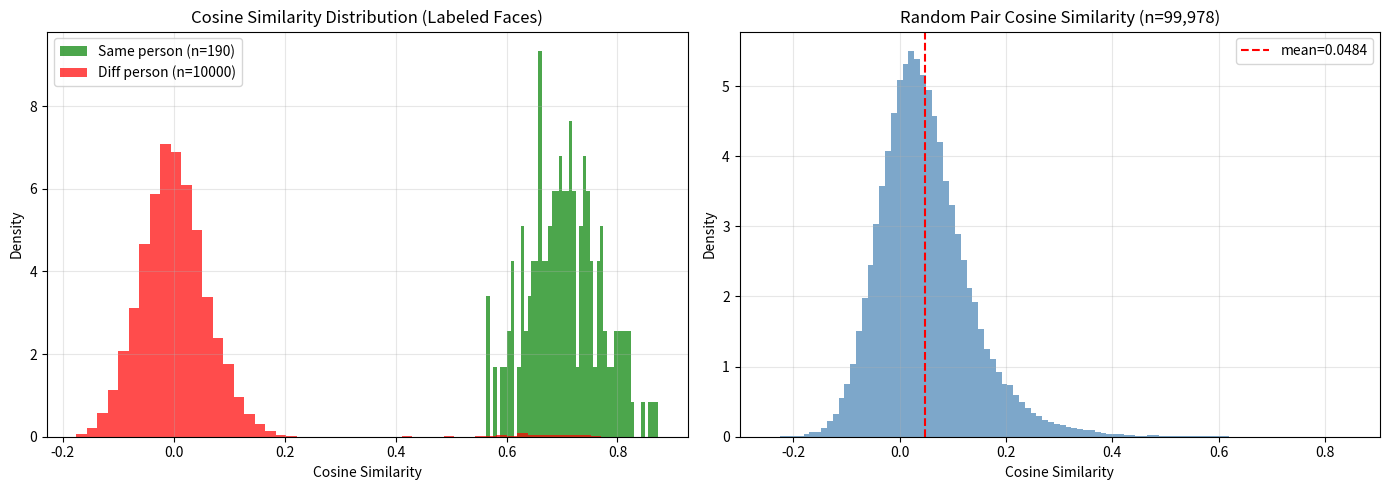

Random pairs - mean: 0.0484, std: 0.0871
Random pairs - median: 0.0380


In [4]:
# 類似度分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) ヒストグラム
axes[0].hist(same_person_sims, bins=50, alpha=0.7, color="green", label=f"Same person (n={len(same_person_sims)})", density=True)
axes[0].hist(diff_person_sims, bins=50, alpha=0.7, color="red", label=f"Diff person (n={len(diff_person_sims)})", density=True)
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Density")
axes[0].set_title("Cosine Similarity Distribution (Labeled Faces)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) 全体のコサイン類似度分布（ランダムサンプリング）
rng = np.random.default_rng(42)
n_sample = min(5000, len(embeddings))
sample_idx = rng.choice(len(embeddings), n_sample, replace=False)
sample_emb = embeddings[sample_idx]
# L2正規化
sample_norms = norm(sample_emb, axis=1, keepdims=True)
sample_emb_normed = sample_emb / sample_norms

# ランダムペアの類似度
n_pairs = 100_000
idx1 = rng.choice(n_sample, n_pairs)
idx2 = rng.choice(n_sample, n_pairs)
# 自己ペアを除外
mask = idx1 != idx2
idx1, idx2 = idx1[mask], idx2[mask]
random_sims = np.sum(sample_emb_normed[idx1] * sample_emb_normed[idx2], axis=1)

axes[1].hist(random_sims, bins=100, alpha=0.7, color="steelblue", density=True)
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Random Pair Cosine Similarity (n={len(random_sims):,})")
axes[1].axvline(x=random_sims.mean(), color="r", linestyle="--", label=f"mean={random_sims.mean():.4f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Random pairs - mean: {random_sims.mean():.4f}, std: {random_sims.std():.4f}")
print(f"Random pairs - median: {np.median(random_sims):.4f}")

## 3. PCA 2D/3D 可視化

ラベル付き顔を PCA で2次元・3次元に射影し、人物ごとのクラスタ形成を確認する。

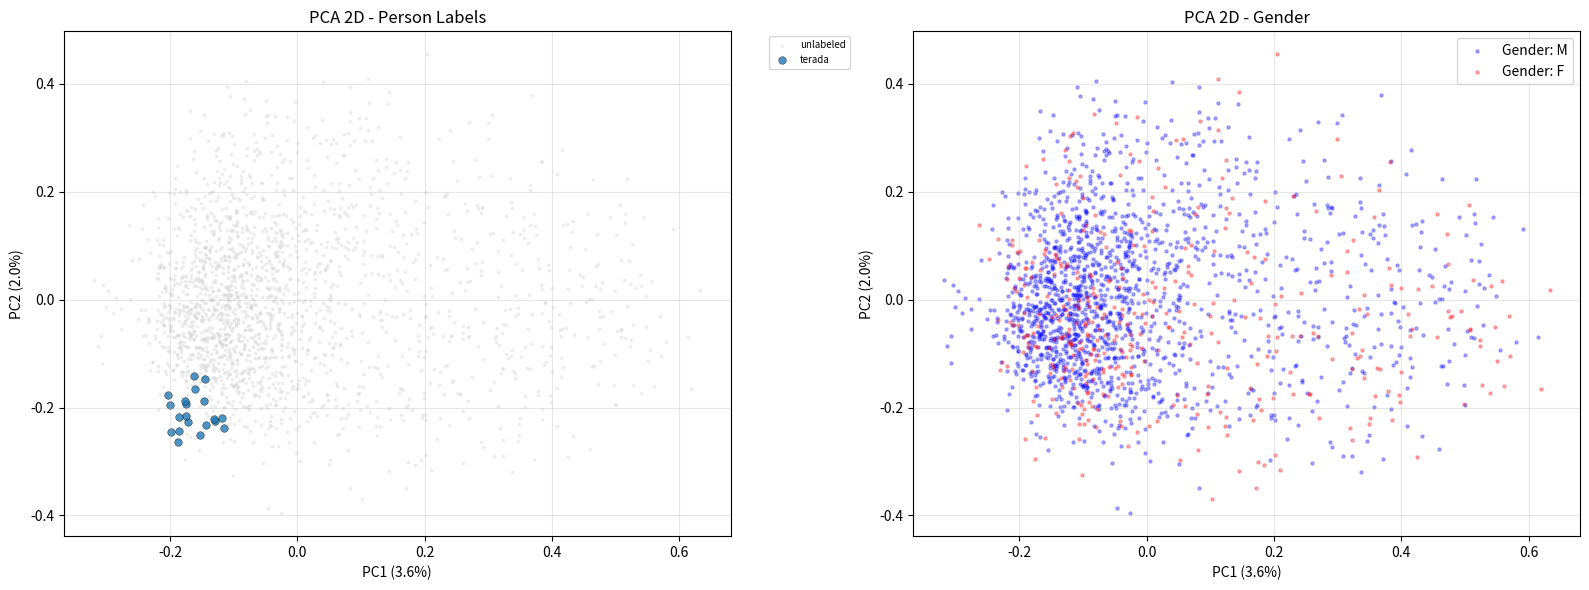

PCA explained variance ratios: [0.03563413 0.02042233 0.01770964]


In [5]:
from sklearn.decomposition import PCA

# ラベル付き顔 + 背景としてランダムサンプル
bg_idx = rng.choice(len(embeddings), min(2000, len(embeddings)), replace=False)
bg_emb = embeddings[bg_idx]

# 全データでPCA学習、ラベル付き + 背景を射影
pca = PCA(n_components=3)
pca.fit(embeddings)  # 全データで学習

labeled_pca = pca.transform(labeled_emb)
bg_pca = pca.transform(bg_emb)

# 2D 可視化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) person_label でカラーリング
unique_labels = sorted(set(labels))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
label_to_color = dict(zip(unique_labels, colors))

axes[0].scatter(bg_pca[:, 0], bg_pca[:, 1], c="lightgray", s=3, alpha=0.3, label="unlabeled")
for label in unique_labels:
    mask = labels == label
    axes[0].scatter(labeled_pca[mask, 0], labeled_pca[mask, 1],
                    c=[label_to_color[label]], s=30, alpha=0.8, label=label, edgecolors="k", linewidths=0.3)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA 2D - Person Labels")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
axes[0].grid(True, alpha=0.3)

# (b) gender でカラーリング（全背景サンプル）
bg_genders = df.iloc[bg_idx]["gender"].values
gender_colors = {"M": "blue", "F": "red"}
for g, c in gender_colors.items():
    mask = bg_genders == g
    axes[1].scatter(bg_pca[mask, 0], bg_pca[mask, 1], c=c, s=5, alpha=0.3, label=f"Gender: {g}")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA 2D - Gender")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PCA explained variance ratios: {pca.explained_variance_ratio_}")

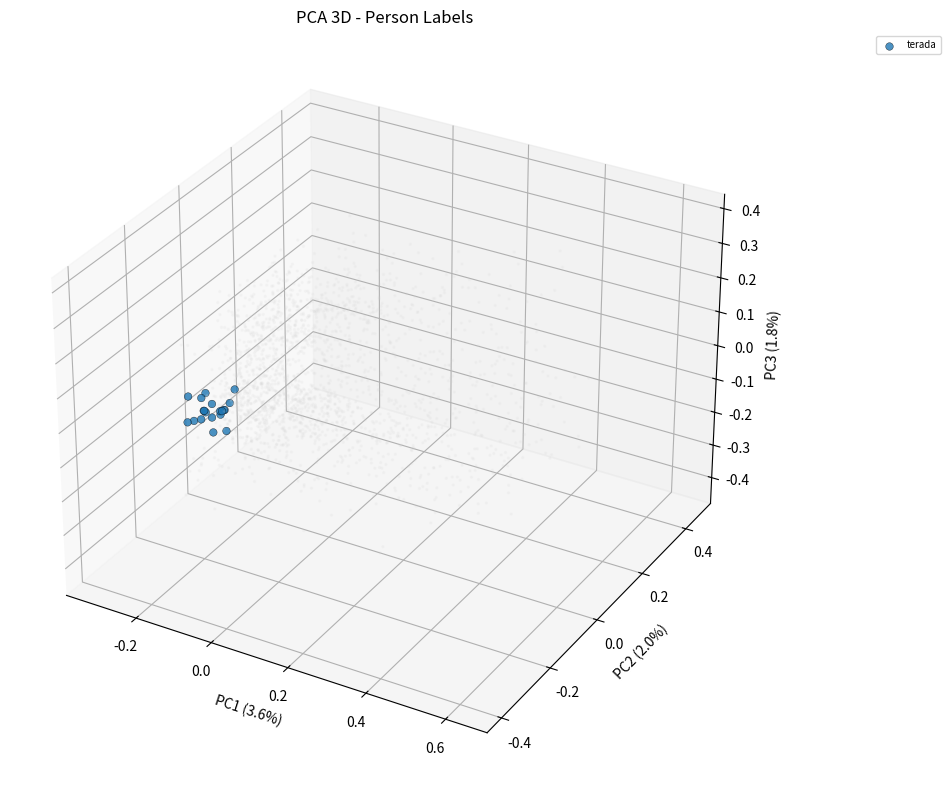

In [6]:
# 3D 可視化
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(bg_pca[:, 0], bg_pca[:, 1], bg_pca[:, 2], c="lightgray", s=2, alpha=0.1)
for label in unique_labels:
    mask = labels == label
    ax.scatter(labeled_pca[mask, 0], labeled_pca[mask, 1], labeled_pca[mask, 2],
               c=[label_to_color[label]], s=30, alpha=0.8, label=label, edgecolors="k", linewidths=0.3)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("PCA 3D - Person Labels")
ax.legend(bbox_to_anchor=(1.15, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

## 4. 年齢分布とクラスタ特性

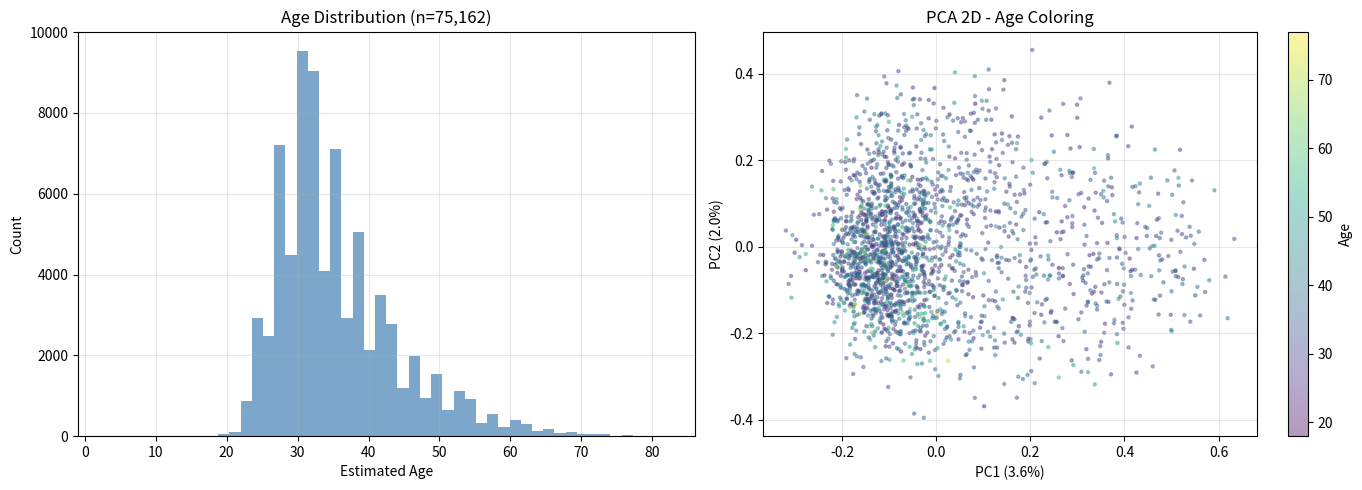

Gender distribution: {'M': 60575, 'F': 14587}
Age stats: mean=35.6, median=34.0, std=8.6


In [7]:
# 年齢 × 性別の分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 年齢分布
ages = df["age"].dropna().values
axes[0].hist(ages, bins=50, color="steelblue", alpha=0.7)
axes[0].set_xlabel("Estimated Age")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Age Distribution (n={len(ages):,})")
axes[0].grid(True, alpha=0.3)

# PCA 2D - 年齢カラーリング
bg_ages = df.iloc[bg_idx]["age"].values
valid_age = ~np.isnan(bg_ages.astype(float))
scatter = axes[1].scatter(bg_pca[valid_age, 0], bg_pca[valid_age, 1],
                          c=bg_ages[valid_age].astype(float), cmap="viridis", s=5, alpha=0.4)
plt.colorbar(scatter, ax=axes[1], label="Age")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA 2D - Age Coloring")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 基本統計
print(f"Gender distribution: {df['gender'].value_counts().to_dict()}")
print(f"Age stats: mean={ages.mean():.1f}, median={np.median(ages):.1f}, std={ages.std():.1f}")

## 5. ハミング距離 vs コサイン類似度の予備分析

ITQ-LSH でハミング距離がコサイン類似度の良い近似になるかを、
SimHash（ランダム超平面）で予備的に確認する。

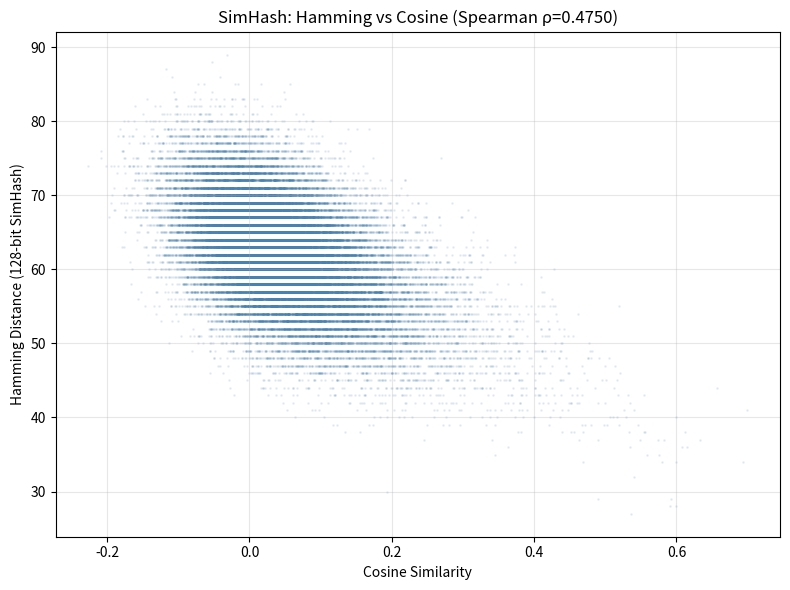

Spearman correlation (cosine sim vs -hamming dist): ρ=0.4750, p=0.00e+00
Hamming distance stats: mean=62.1, std=6.7
Hamming range: [27, 89] / 128 bits


In [8]:
from image_vector_poc.search.lsh.simhash import SimHashGenerator, hamming_distance as sh_hamming
from scipy.stats import spearmanr

# SimHash でハッシュ生成（128bit）
simhash = SimHashGenerator(dim=512, hash_bits=128, seed=42)

# サンプルデータでテスト
rng = np.random.default_rng(42)
n_test = 2000
test_idx = rng.choice(len(embeddings), n_test, replace=False)
test_emb = embeddings[test_idx]
test_norms = norm(test_emb, axis=1, keepdims=True)
test_emb_normed = test_emb / test_norms

# SimHash 生成
test_hashes = simhash.hash_batch(test_emb_normed)

# ランダムペアでハミング距離 vs コサイン類似度
n_pairs = 50_000
p1 = rng.choice(n_test, n_pairs)
p2 = rng.choice(n_test, n_pairs)
mask = p1 != p2
p1, p2 = p1[mask], p2[mask]

cosine_sims = np.sum(test_emb_normed[p1] * test_emb_normed[p2], axis=1)
hamming_dists = np.array([sh_hamming(test_hashes[i], test_hashes[j]) for i, j in zip(p1, p2)])

# Spearman相関
rho, pval = spearmanr(cosine_sims, -hamming_dists)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cosine_sims, hamming_dists, s=1, alpha=0.1, color="steelblue")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Hamming Distance (128-bit SimHash)")
ax.set_title(f"SimHash: Hamming vs Cosine (Spearman ρ={rho:.4f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Spearman correlation (cosine sim vs -hamming dist): ρ={rho:.4f}, p={pval:.2e}")
print(f"Hamming distance stats: mean={hamming_dists.mean():.1f}, std={hamming_dists.std():.1f}")
print(f"Hamming range: [{hamming_dists.min()}, {hamming_dists.max()}] / 128 bits")

## 6. 次元ごとの分布と有効次元数

各次元の値の分布を確認し、ArcFace 埋め込みの利用効率を分析する。

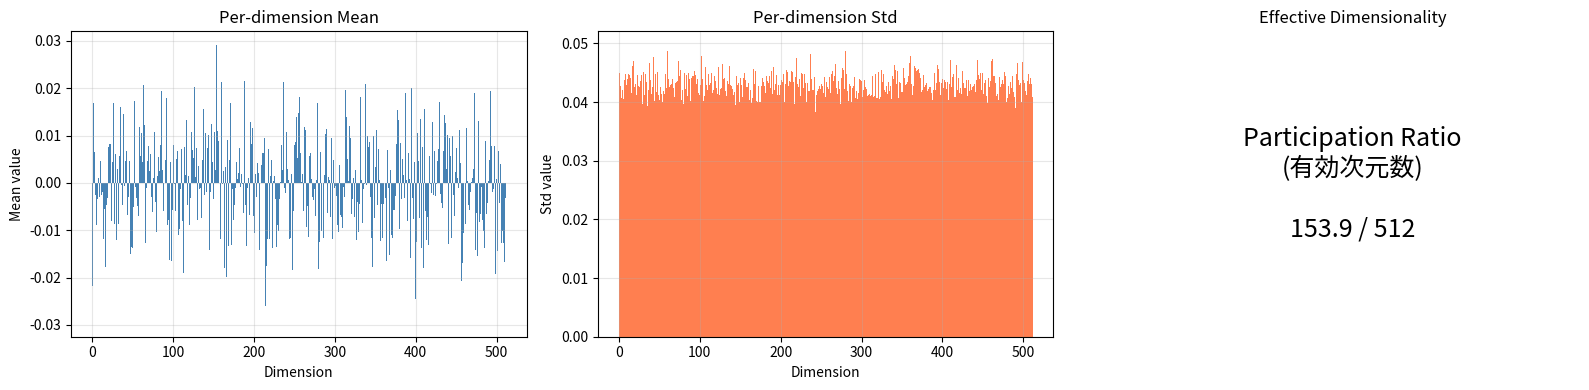

有効次元数 (Participation Ratio): 153.9 / 512 (30.1%)
次元平均の統計: mean_of_means=-0.000284, std_of_means=0.009677
次元標準偏差の統計: mean_of_stds=0.043080, std_of_stds=0.001878


In [9]:
# 次元ごとの統計
dim_means = embeddings.mean(axis=0)
dim_stds = embeddings.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) 次元ごとの平均値
axes[0].bar(range(512), dim_means, color="steelblue", width=1.0)
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Mean value")
axes[0].set_title("Per-dimension Mean")
axes[0].grid(True, alpha=0.3)

# (b) 次元ごとの標準偏差
axes[1].bar(range(512), dim_stds, color="coral", width=1.0)
axes[1].set_xlabel("Dimension")
axes[1].set_ylabel("Std value")
axes[1].set_title("Per-dimension Std")
axes[1].grid(True, alpha=0.3)

# (c) 有効次元数（participation ratio）
# PR = (Σλ_i)^2 / Σλ_i^2
pr = eigenvalues.sum()**2 / (eigenvalues**2).sum()
axes[2].text(0.5, 0.5, f"Participation Ratio\n(有効次元数)\n\n{pr:.1f} / 512",
             transform=axes[2].transAxes, ha="center", va="center", fontsize=18)
axes[2].set_title("Effective Dimensionality")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"有効次元数 (Participation Ratio): {pr:.1f} / 512 ({pr/512*100:.1f}%)")
print(f"次元平均の統計: mean_of_means={dim_means.mean():.6f}, std_of_means={dim_means.std():.6f}")
print(f"次元標準偏差の統計: mean_of_stds={dim_stds.mean():.6f}, std_of_stds={dim_stds.std():.6f}")

## 7. まとめと ITQ 適用への考察

In [10]:
# 分析結果サマリー
print("=" * 60)
print("ArcFace 512次元 空間特性分析サマリー")
print("=" * 60)
print(f"\n【データ規模】")
print(f"  総顔数: {len(df):,}")
print(f"  ラベル付き顔数: {labeled_mask.sum()}")
print(f"  次元数: 512")

print(f"\n【異方性】")
print(f"  条件数: {isotropy['condition_number']:.2f}")
print(f"  Top-10 寄与率: {isotropy['top10_variance_ratio']*100:.1f}%")
print(f"  有効次元数 (PR): {pr:.1f} / 512 ({pr/512*100:.1f}%)")

print(f"\n【コサイン類似度分布】")
print(f"  同一人物: mean={same_person_sims.mean():.4f} ± {same_person_sims.std():.4f}")
print(f"  他人:     mean={diff_person_sims.mean():.4f} ± {diff_person_sims.std():.4f}")
print(f"  ランダム: mean={random_sims.mean():.4f} ± {random_sims.std():.4f}")
print(f"  Fisher分離度: {separation:.4f}")

print(f"\n【SimHash 予備評価 (128bit)】")
print(f"  Spearman ρ: {rho:.4f}")

print(f"\n【ITQ ビット数と累積寄与率】")
for n_bits in [64, 96, 128, 256]:
    if n_bits <= len(cumvar):
        print(f"  {n_bits} bits → {cumvar[n_bits-1]*100:.1f}%")

print(f"\n【ITQ 適用への見通し】")
print("  - 512次元は1024次元より低次元 → PCA での情報損失が少ない")
print("  - L2正規化済み → コサイン類似度 = 内積 → SimHash/ITQ と相性良好")
print("  - 同一人物 vs 他人の分離が明確 → LSH でも区別可能な見込み")
print("  → NB92 で ITQ 学習とハッシュ品質評価へ進む")

conn.close()

ArcFace 512次元 空間特性分析サマリー

【データ規模】
  総顔数: 75,162
  ラベル付き顔数: 20
  次元数: 512

【異方性】
  条件数: 85007.87
  Top-10 寄与率: 16.2%
  有効次元数 (PR): 153.9 / 512 (30.1%)

【コサイン類似度分布】
  同一人物: mean=0.7048 ± 0.0647
  他人:     mean=0.0067 ± 0.0870
  ランダム: mean=0.0484 ± 0.0871
  Fisher分離度: 4.6014

【SimHash 予備評価 (128bit)】
  Spearman ρ: 0.4750

【ITQ ビット数と累積寄与率】
  64 bits → 50.5%
  96 bits → 61.9%
  128 bits → 70.3%
  256 bits → 90.3%

【ITQ 適用への見通し】
  - 512次元は1024次元より低次元 → PCA での情報損失が少ない
  - L2正規化済み → コサイン類似度 = 内積 → SimHash/ITQ と相性良好
  - 同一人物 vs 他人の分離が明確 → LSH でも区別可能な見込み
  → NB92 で ITQ 学習とハッシュ品質評価へ進む


## 評価・考察

### 異方性について
- **条件数 85,008**: 非常に大きく、強い異方性を示す。一部の主成分に分散が集中しており、PCA による次元削減の効果が期待できる
- **Top-10 寄与率 16.2%**: 上位10成分で全分散の16%を占める。E5テキスト埋め込み（1024次元）と比較すると、512次元で情報がより均等に分布している
- **有効次元数 153.9 / 512 (30.1%)**: 512次元のうち約154次元が実質的に使われている。128bit への ITQ 圧縮は情報損失が一定あるが、累積寄与率70.3%を保持

### コサイン類似度分布
- **同一人物 mean=0.705 vs 他人 mean=0.007**: 明確な分離（Fisher=4.60）。ArcFace は人物識別に十分な識別力を持つ
- **ランダムペア mean=0.048**: ほぼ直交に近い。高次元空間での「空間の呪い」が見える（ランダムベクトル間の類似度が0に集中）
- **同一人物の最小値 0.564**: 同一人物でも表情・角度・照明によるばらつきがある

### SimHash 予備評価
- **Spearman ρ=0.475**: ランダム超平面による SimHash は中程度の相関にとどまる。ITQ による最適化で改善が期待される（NB92 で検証）

### ITQ 適用への見通し
- 128bit で累積寄与率 70.3% → 検索精度に影響する可能性あるが、カスケード（リランキング付き）で補完可能
- 256bit で 90.3% → 精度重視なら選択肢だが、ハッシュサイズとのトレードオフ
- L2正規化済みで単位超球面上に分布 → コサイン類似度保存型の LSH と自然に適合
- 75K faces は規模として中程度。HNSW と比較して ITQ-LSH が有利になるのは 100K+ と予想